In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("citibike_2022_merged_weather.csv")

/var/folders/r7/hpnbv35s3194ffb_bhsw50nc0000gn/T/ipykernel_1519/2712742824.py:1: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("citibike_2022_merged_weather.csv")


In [6]:
import pandas as pd

df = pd.read_csv("citibike_2022_merged_weather.csv", low_memory=False)
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,date,AWND,PRCP,TMAX,TMIN
0,3A2034DA67C8874B,electric_bike,2022-09-14 20:37:39.155,2022-09-14 21:05:39.760,N 12 St & Bedford Ave,5450.04,Albany St & Greenwich St,5145.02,40.720796,-73.954882,40.709267,-74.013247,casual,2022-09-14,5.2,0.0,26.7,18.3
1,F1C63DACDCC1C33D,electric_bike,2022-09-17 19:21:39.407,2022-09-17 20:08:32.670,Union Ave & Jackson St,5300.06,Metropolitan Ave & Meeker Ave,5300.05,40.716075,-73.952029,40.714133,-73.952344,casual,2022-09-17,4.2,0.0,23.3,18.3
2,94372C52777F4AC1,electric_bike,2022-09-17 16:49:21.830,2022-09-17 17:01:51.537,S 4 St & Wythe Ave,5204.05,St Marks Pl & 1 Ave,5626.13,40.712874,-73.965935,40.727791,-73.985649,casual,2022-09-17,4.2,0.0,23.3,18.3
3,44818FEC94B62B66,electric_bike,2022-09-08 12:27:40.019,2022-09-08 12:47:15.649,Amsterdam Ave & W 73 St,7260.09,Washington St & Gansevoort St,6039.06,40.779668,-73.980930,40.739323,-74.008119,casual,2022-09-08,3.5,0.0,25.6,18.3
4,F8A63709F214EBAA,classic_bike,2022-09-16 19:00:19.266,2022-09-16 19:07:28.905,University Pl & E 14 St,5905.14,Washington St & Gansevoort St,6039.06,40.734814,-73.992085,40.739323,-74.008119,member,2022-09-16,2.6,0.0,25.0,15.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1163216 entries, 0 to 1163215
Data columns (total 18 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   ride_id             1163216 non-null  object 
 1   rideable_type       1163216 non-null  object 
 2   started_at          1163216 non-null  object 
 3   ended_at            1163216 non-null  object 
 4   start_station_name  1163216 non-null  object 
 5   start_station_id    1163216 non-null  object 
 6   end_station_name    1155488 non-null  object 
 7   end_station_id      1155488 non-null  object 
 8   start_lat           1163216 non-null  float64
 9   start_lng           1163216 non-null  float64
 10  end_lat             1159419 non-null  float64
 11  end_lng             1159419 non-null  float64
 12  member_casual       1163216 non-null  object 
 13  date                1163216 non-null  object 
 14  AWND                1163215 non-null  float64
 15  PRCP           

<Axes: xlabel='date'>

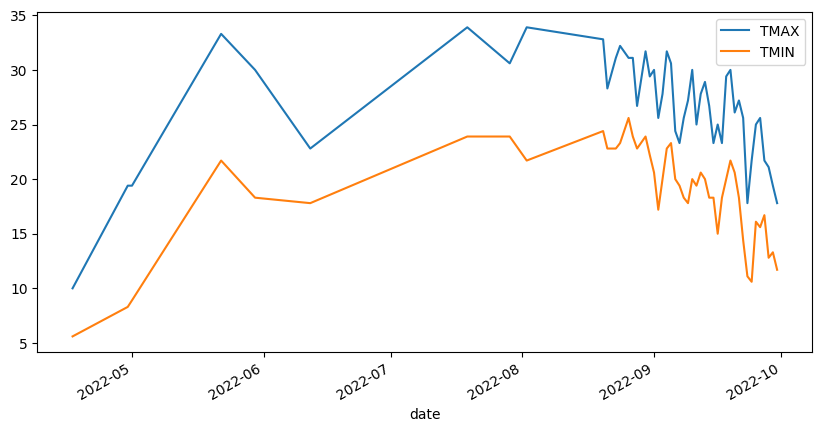

In [8]:
df["date"] = pd.to_datetime(df["date"])

df.plot(
    x="date",
    y=["TMAX", "TMIN"],
    kind="line",
    figsize=(10, 5)
)

In [11]:
df["date"] = pd.to_datetime(df["date"])

daily_trips = df.groupby("date").size().reset_index(name="trip_count")

df = pd.merge(df, daily_trips, on="date", how="left")

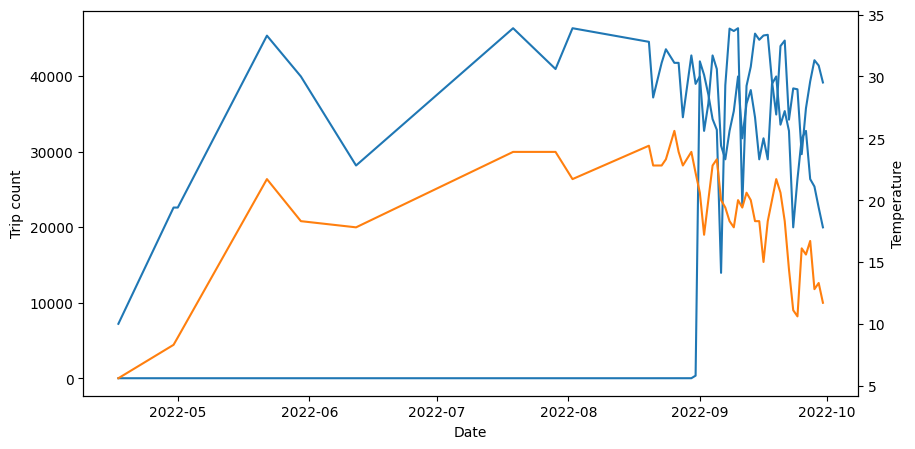

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])


daily = df.groupby("date", as_index=False).agg(
    trip_count=("ride_id", "size"),
    TMAX=("TMAX", "mean"),
    TMIN=("TMIN", "mean")
)


daily = daily[(daily["date"] >= "2022-01-01") & (daily["date"] <= "2022-12-31")].sort_values("date")

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(daily["date"], daily["trip_count"])
ax1.set_xlabel("Date")
ax1.set_ylabel("Trip count")

ax2 = ax1.twinx()
ax2.plot(daily["date"], daily["TMAX"])
ax2.plot(daily["date"], daily["TMIN"])
ax2.set_ylabel("Temperature")

plt.show()

Matplotlib was used to create a dual-axis line chart by plotting bike trip counts on one axis and temperatures on a second axis using twinx(). The object-oriented paradigm was used by directly working with figure and axis objects.